In [5]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
datasets = ['SPY', 'QQQ', 'IWM', 'DIA']

df = yf.download(datasets, start='2010-01-01', end='2020-06-30')

# work only with close prices for all tickers
close = df['Close'].squeeze()

# percentage returns for each ticker
returns = close.pct_change()
returns = returns.dropna()

print(returns.head())

features = pd.DataFrame(index=close.index)

# aggregate features across all datasets
features['volatility'] = returns.rolling(window=20).std().mean(axis=1)
features['skewness'] = returns.rolling(window=20).skew().mean(axis=1)
features['avg_return'] = returns.rolling(window=20).mean().mean(axis=1)
features['drawdown'] = (close / close.rolling(20).max() - 1).mean(axis=1)
features['trend'] = (close / close.rolling(20).mean()).mean(axis=1)
features['vol_change'] = features['volatility'].diff()
features['dispersion'] = returns.std(axis=1)

features = features.dropna()
print(features.head())




[*********************100%***********************]  4 of 4 completed

Ticker           DIA       IWM       QQQ       SPY
Date                                              
2010-01-05 -0.001609 -0.003439  0.000000  0.002647
2010-01-06  0.000664 -0.000941 -0.006031  0.000704
2010-01-07  0.003600  0.007378  0.000650  0.004221
2010-01-08  0.001604  0.005454  0.008231  0.003328
2010-01-11  0.004053 -0.004030 -0.004082  0.001396
            volatility  skewness  avg_return  drawdown     trend  vol_change  \
Date                                                                           
2010-02-03    0.011134 -0.343704   -0.001944 -0.050976  0.978131    0.000041   
2010-02-04    0.012737 -0.483876   -0.003354 -0.079063  0.952393    0.001603   
2010-02-05    0.012735 -0.479936   -0.003357 -0.075486  0.959363   -0.000002   
2010-02-08    0.012635 -0.339097   -0.004012 -0.083290  0.955142   -0.000100   
2010-02-09    0.013158 -0.340328   -0.003340 -0.071581  0.970671    0.000523   

            dispersion  
Date                    
2010-02-03    0.005385  
2010-02

In [34]:
#normalize features before clustering

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

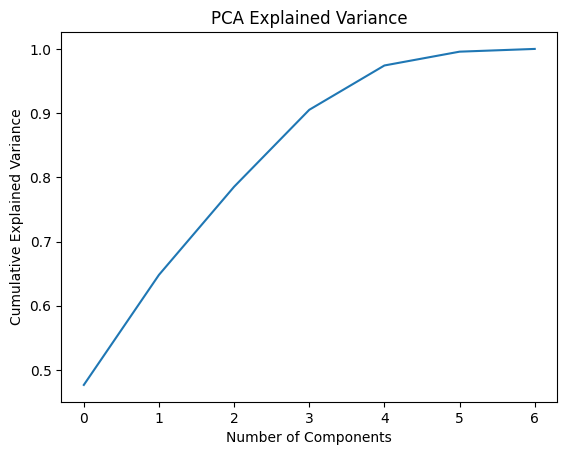

In [43]:
#get cumulative explained variance for PCA
pca = PCA().fit(scaled_features)
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

#use PCA to reduce dimensionality for visualization
pca = PCA(n_components=4).fit_transform(scaled_features)

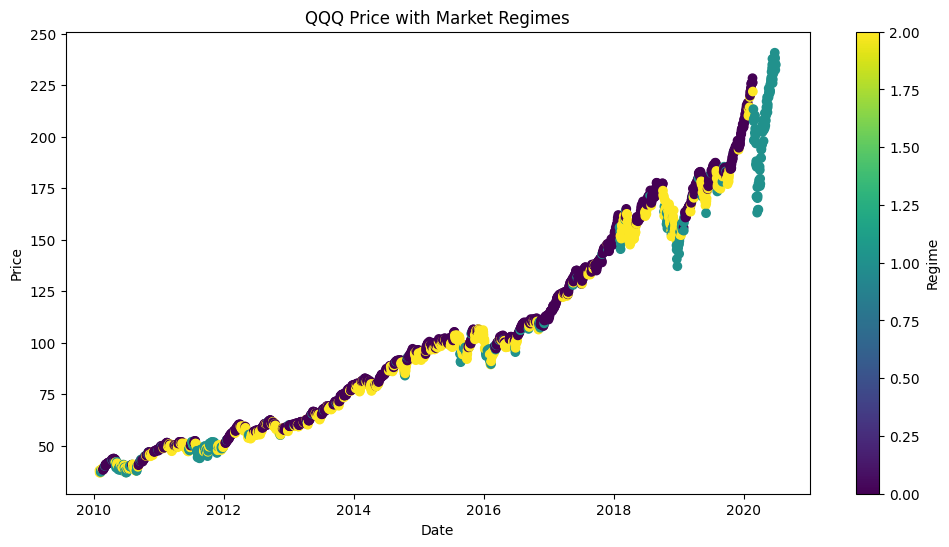

In [45]:
# run GMM clustering
gmm = GaussianMixture(n_components=3, random_state=42)
regime = gmm.fit_predict(scaled_features)

# plot regimes
plt.figure(figsize=(12, 6))
plt.scatter(features.index, close.loc[features.index, 'QQQ'], c=regime, cmap='viridis', marker='o')
plt.title('QQQ Price with Market Regimes')
plt.xlabel('Date')
plt.ylabel('Price')
plt.colorbar(label='Regime')
plt.show()

In [46]:
#calc silhouette score
for k in range(2, 20):
    gmm = GaussianMixture(n_components=k, random_state=42)
    regime = gmm.fit_predict(scaled_features)

    score = silhouette_score(scaled_features, regime)
    print(f'Silhouette Score for {k} clusters: {score:.2f}')

Silhouette Score for 2 clusters: 0.32
Silhouette Score for 3 clusters: 0.14
Silhouette Score for 4 clusters: 0.14
Silhouette Score for 5 clusters: 0.08
Silhouette Score for 6 clusters: 0.04
Silhouette Score for 7 clusters: 0.00
Silhouette Score for 8 clusters: 0.04
Silhouette Score for 9 clusters: 0.01
Silhouette Score for 10 clusters: 0.01
Silhouette Score for 11 clusters: -0.01
Silhouette Score for 12 clusters: -0.01
Silhouette Score for 13 clusters: 0.03
Silhouette Score for 14 clusters: 0.01
Silhouette Score for 15 clusters: 0.02
Silhouette Score for 16 clusters: -0.00
Silhouette Score for 17 clusters: -0.00
Silhouette Score for 18 clusters: 0.01
Silhouette Score for 19 clusters: -0.00


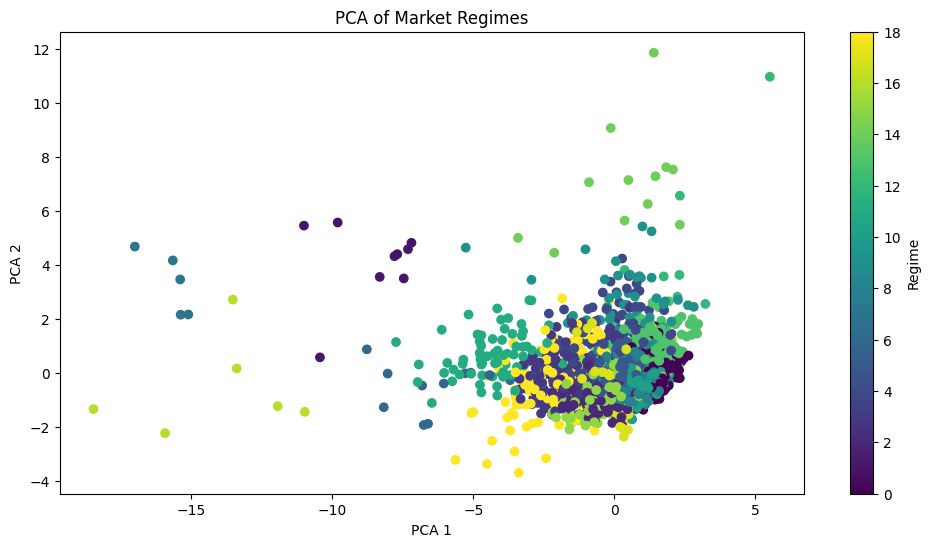

In [41]:
# plot PCA visualization of regimes
plt.figure(figsize=(12, 6))
plt.scatter(pca[:, 0], pca[:, 1], c=regime, cmap='viridis', marker='o')
plt.title('PCA of Market Regimes')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.colorbar(label='Regime')
plt.show()

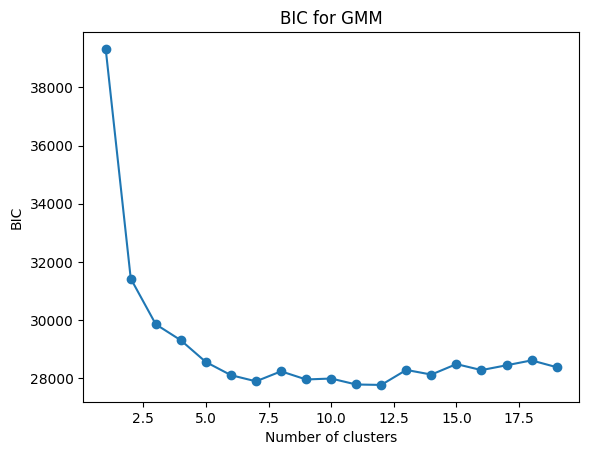

In [ ]:
#calc bayesian information criterion for GMM
bic = []
for k in range(1, 20):
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(scaled_features)
    bic.append(gmm.bic(scaled_features))

plt.plot(range(1, 20), bic, marker='o')
plt.title('BIC for GMM')
plt.xlabel('Number of clusters')
plt.ylabel('BIC')
plt.show()

